# Time Series Forecasting Per Role (Prophet + ARIMA)

This notebook builds a full per-role demand forecasting pipeline from raw job postings data.

Pipeline flow:
1. Load raw job postings
2. Clean data with exact feature names
3. Convert dates
4. Aggregate monthly per role
5. Prepare time series features
6. Train Prophet model per role
7. Optionally train ARIMA per role
8. Forecast future demand
9. Use cross-validation for evaluation
10. Compute trend slope per role
11. Rank roles by trend
12. Plot forecasts
13. Save trained models and outputs

In [1]:
# Step 1: Install and import libraries
try:
    from prophet import Prophet
except Exception:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "prophet", "-q"])
    from prophet import Prophet

from pathlib import Path
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Job_pipeline").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "Job_pipeline" / "data" / "processed" / "afriwork_all_jobs_20260310_124628.csv"

OUTPUT_DIR = PROJECT_ROOT / "model" / "timeseries" / "artifacts"
MODELS_DIR = OUTPUT_DIR / "models" / "prophet"
FORECASTS_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"

for folder in [OUTPUT_DIR, MODELS_DIR, FORECASTS_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dataset: {DATA_PATH}")
print(f"Artifacts directory: {OUTPUT_DIR}")

Project root: c:\Users\user\Desktop\5th\VentureScope\Data-ML
Input dataset: c:\Users\user\Desktop\5th\VentureScope\Data-ML\Job_pipeline\data\processed\afriwork_all_jobs_20260310_124628.csv
Artifacts directory: c:\Users\user\Desktop\5th\VentureScope\Data-ML\model\timeseries\artifacts


In [2]:
# Step 2: Load dataset and clean using exact feature names
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")

required_columns = {"normalized_title", "job_id"}
missing_required = required_columns.difference(raw_df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

date_source_col = None
for candidate in ["timestamp", "year_month", "month"]:
    if candidate in raw_df.columns:
        date_source_col = candidate
        break

if date_source_col is None:
    raise ValueError("Expected one of date columns: ['timestamp', 'year_month', 'month']")

df = raw_df.copy()
df["event_date"] = pd.to_datetime(df[date_source_col], errors="coerce")
df["role"] = df["normalized_title"].astype(str).str.strip()

before_dedup = len(df)
df = df.drop_duplicates(subset=["job_id"])
print(f"Removed duplicates by job_id: {before_dedup - len(df)}")

df = df.dropna(subset=["role", "event_date"]).copy()
df = df[df["role"] != ""]

print(f"Using date source column: {date_source_col}")
print(f"Cleaned shape: {df.shape}")
df[["normalized_title", "role", date_source_col, "event_date"]].head()

Raw shape: (3105, 15)
Removed duplicates by job_id: 231
Using date source column: timestamp
Cleaned shape: (2564, 17)


,normalized_title,role,timestamp,event_date
0,Frontend Developer,Frontend Developer,2023-05-02T12:21:08.391921+00:00,2023-05-02 12:21:08.391921+00:00
1,Mobile Developer,Mobile Developer,2026-03-09T13:12:52.043397+00:00,2026-03-09 13:12:52.043397+00:00
2,Data Analyst,Data Analyst,2026-03-09T08:07:18.877749+00:00,2026-03-09 08:07:18.877749+00:00
3,UI/UX Designer,UI/UX Designer,2026-03-07T10:13:36.992229+00:00,2026-03-07 10:13:36.992229+00:00
4,Other,Other,2026-03-06T20:44:53.344375+00:00,2026-03-06 20:44:53.344375+00:00


In [3]:
# Step 3: Aggregate monthly job counts per role
df["month"] = df["event_date"].dt.to_period("M")

aggregated_df = (
    df.groupby(["role", "month"], as_index=False)
    .size()
    .rename(columns={"size": "job_count"})
)
aggregated_df["month"] = aggregated_df["month"].dt.to_timestamp()

# Final modeling table required by the prompt: month | role | job_count
modeling_df = aggregated_df[["month", "role", "job_count"]].sort_values(["role", "month"]).reset_index(drop=True)

print("Modeling dataset structure:", modeling_df.columns.tolist())
print(f"Modeling shape: {modeling_df.shape}")
modeling_df.head(10)

Modeling dataset structure: ['month', 'role', 'job_count']
Modeling shape: (622, 3)


,month,role,job_count
0,2023-01-01,AI Engineer,1
1,2023-02-01,AI Engineer,1
2,2023-03-01,AI Engineer,1
3,2023-05-01,AI Engineer,4
4,2023-06-01,AI Engineer,3
5,2023-07-01,AI Engineer,2
6,2023-08-01,AI Engineer,2
7,2023-09-01,AI Engineer,2
8,2023-11-01,AI Engineer,3
9,2023-12-01,AI Engineer,1


In [4]:
# Step 4 and Step 5: Prepare per-role time series and train Prophet
horizon_months = 6
prophet_models = {}
prophet_forecasts = {}
role_series_for_prophet = {}
skipped_prophet_roles = {}

for role, role_df in modeling_df.groupby("role"):
    ts_df = role_df.sort_values("month")[["month", "job_count"]].rename(columns={"month": "ds", "job_count": "y"})
    role_series_for_prophet[role] = ts_df

    if len(ts_df) < 2:
        skipped_prophet_roles[role] = "Not enough points (<2)."
        continue

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(ts_df)

    future = model.make_future_dataframe(periods=horizon_months, freq="MS")
    forecast = model.predict(future)

    prophet_models[role] = model
    prophet_forecasts[role] = forecast

print(f"Trained Prophet models: {len(prophet_models)}")
print(f"Skipped roles (Prophet): {len(skipped_prophet_roles)}")
if skipped_prophet_roles:
    print("Example skips:", dict(list(skipped_prophet_roles.items())[:5]))

02:16:14 - cmdstanpy - INFO - Chain [1] start processing
02:16:15 - cmdstanpy - INFO - Chain [1] done processing
02:16:15 - cmdstanpy - INFO - Chain [1] start processing
02:16:15 - cmdstanpy - INFO - Chain [1] done processing
02:16:16 - cmdstanpy - INFO - Chain [1] start processing
02:16:17 - cmdstanpy - INFO - Chain [1] done processing
02:16:17 - cmdstanpy - INFO - Chain [1] start processing
02:16:17 - cmdstanpy - INFO - Chain [1] done processing
02:16:17 - cmdstanpy - INFO - Chain [1] start processing
02:16:18 - cmdstanpy - INFO - Chain [1] done processing
02:16:18 - cmdstanpy - INFO - Chain [1] start processing
02:16:18 - cmdstanpy - INFO - Chain [1] done processing
02:16:19 - cmdstanpy - INFO - Chain [1] start processing
02:16:19 - cmdstanpy - INFO - Chain [1] done processing
02:16:19 - cmdstanpy - INFO - Chain [1] start processing
02:16:19 - cmdstanpy - INFO - Chain [1] done processing
02:16:20 - cmdstanpy - INFO - Chain [1] start processing
02:16:20 - cmdstanpy - INFO - Chain [1]

Trained Prophet models: 21
Skipped roles (Prophet): 1
Example skips: {'Embedded Systems Engineer': 'Not enough points (<2).'}


In [5]:
# Step 6: Optional ARIMA per role
arima_models = {}
arima_forecasts = {}
skipped_arima_roles = {}

for role, role_df in modeling_df.groupby("role"):
    ts = role_df.sort_values("month").set_index("month")["job_count"].asfreq("MS", fill_value=0)

    if len(ts) < 6:
        skipped_arima_roles[role] = "Not enough points for ARIMA (<6)."
        continue

    try:
        arima_model = ARIMA(ts, order=(1, 1, 1)).fit()
        arima_pred = arima_model.forecast(steps=horizon_months)
        future_index = pd.date_range(ts.index.max() + pd.offsets.MonthBegin(1), periods=horizon_months, freq="MS")

        arima_models[role] = arima_model
        arima_forecasts[role] = pd.DataFrame({"ds": future_index, "yhat": arima_pred.values})
    except Exception as exc:
        skipped_arima_roles[role] = str(exc)

print(f"Trained ARIMA models: {len(arima_models)}")
print(f"Skipped roles (ARIMA): {len(skipped_arima_roles)}")
if skipped_arima_roles:
    print("Example skips:", dict(list(skipped_arima_roles.items())[:5]))

Trained ARIMA models: 21
Skipped roles (ARIMA): 1
Example skips: {'Embedded Systems Engineer': 'Not enough points for ARIMA (<6).'}


In [6]:
# Step 7: Evaluate models per role using time-series cross-validation
evaluation_rows = []
cv_horizon_months = 3
min_train_months = 6

for role, role_df in modeling_df.groupby("role"):
    role_ts = role_df.sort_values("month")[["month", "job_count"]].rename(columns={"month": "ds", "job_count": "y"})
    n_points = len(role_ts)

    # Prophet cross-validation
    if n_points >= (min_train_months + cv_horizon_months + 1):
        try:
            cv_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            cv_model.fit(role_ts)

            horizon_days = int(cv_horizon_months * 30)
            initial_days = int(max(min_train_months * 30, (n_points - cv_horizon_months) * 30 * 0.7))
            period_days = max(30, horizon_days // 2)

            cv_df = cross_validation(
                cv_model,
                initial=f"{initial_days} days",
                period=f"{period_days} days",
                horizon=f"{horizon_days} days",
                parallel="processes",
            )

            pm = performance_metrics(cv_df)
            evaluation_rows.append(
                {
                    "role": role,
                    "model": "prophet_cv",
                    "rmse": float(pm["rmse"].mean()),
                    "mae": float(pm["mae"].mean()),
                    "cv_rows": int(len(cv_df)),
                }
            )
        except Exception as exc:
            print(f"Prophet CV skipped for '{role}': {exc}")

    # ARIMA expanding-window cross-validation (1-step ahead)
    if n_points >= (min_train_months + 2):
        y_vals = role_ts["y"].astype(float).values
        y_true = []
        y_pred = []

        for split_idx in range(min_train_months, n_points):
            train_vals = y_vals[:split_idx]
            test_val = y_vals[split_idx]

            try:
                arima_model = ARIMA(train_vals, order=(1, 1, 1)).fit()
                pred_val = float(arima_model.forecast(steps=1)[0])
                y_true.append(float(test_val))
                y_pred.append(pred_val)
            except Exception:
                continue

        if len(y_true) >= 2:
            evaluation_rows.append(
                {
                    "role": role,
                    "model": "arima_cv",
                    "rmse": float(mean_squared_error(y_true, y_pred, squared=False)),
                    "mae": float(mean_absolute_error(y_true, y_pred)),
                    "cv_rows": int(len(y_true)),
                }
            )

evaluation_df = pd.DataFrame(evaluation_rows)
if not evaluation_df.empty:
    evaluation_df = evaluation_df.sort_values(["model", "rmse", "mae"]).reset_index(drop=True)

print(f"Cross-validation evaluation rows: {len(evaluation_df)}")
evaluation_df.head(20)

02:21:08 - cmdstanpy - INFO - Chain [1] start processing
02:21:08 - cmdstanpy - INFO - Chain [1] done processing
02:22:01 - cmdstanpy - INFO - Chain [1] start processing
02:22:02 - cmdstanpy - INFO - Chain [1] done processing
02:22:22 - cmdstanpy - INFO - Chain [1] start processing
02:22:22 - cmdstanpy - INFO - Chain [1] done processing
02:23:12 - cmdstanpy - INFO - Chain [1] start processing
02:23:12 - cmdstanpy - INFO - Chain [1] done processing
02:23:31 - cmdstanpy - INFO - Chain [1] start processing
02:23:31 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
02:23:48 - cmdstanpy - INFO - Chain [1] start processing
02:23:48 - cmdstanpy - INFO - Chain [1] done processing
02:24:54 - cmdstanpy - INFO - Chain [1] start processing
02:24:55 - cmdstanpy - INFO - Chain [1] done processing
02:26:17 - cmdstanpy - INFO - Chain [1] start processing
02:26:18 - cmdstanpy - INFO - Chain [1] done pro

Cross-validation evaluation rows: 38


,role,model,rmse,mae,cv_rows
0,Machine Learning Engineer,arima_cv,0.411893,0.190884,6
1,Data Scientist,arima_cv,0.597846,0.464473,12
2,Site Reliability Engineer,arima_cv,0.860489,0.696446,14
3,QA Engineer,arima_cv,0.913251,0.593336,20
4,AI Engineer,arima_cv,1.003474,0.761641,22
5,DevOps Engineer,arima_cv,1.051031,0.836895,23
6,Systems Administrator,arima_cv,1.084320,0.825835,19
7,Cybersecurity Engineer,arima_cv,1.134100,0.806332,16
8,Data Analyst,arima_cv,1.404221,1.124630,30
9,Network Engineer,arima_cv,1.572590,1.351157,27


In [7]:
# Step 8 and Step 9: Trend score per role and overall ranking
trend_rows = []

for role, forecast_df in prophet_forecasts.items():
    last_forecast = forecast_df.tail(horizon_months).copy()
    if len(last_forecast) < 2:
        continue

    x = np.arange(len(last_forecast))
    yhat = last_forecast["yhat"].values
    slope = np.polyfit(x, yhat, 1)[0]

    trend_rows.append(
        {
            "role": role,
            "trend_score": slope,
            "forecast_mean_next_6m": float(np.mean(yhat)),
        }
    )

trend_df = pd.DataFrame(trend_rows).sort_values("trend_score", ascending=False).reset_index(drop=True)

if trend_df.empty:
    print("No trend ranking available.")
else:
    top_role = trend_df.iloc[0]["role"]
    print(f"Overall trending role: {top_role}")

trend_df.head(20)

Overall trending role: Product Manager


,role,trend_score,forecast_mean_next_6m
0,Product Manager,0.905491,7.012066
1,Site Reliability Engineer,0.806295,1.382319
2,Machine Learning Engineer,0.522439,0.586597
3,AI Engineer,0.449757,2.065783
4,Data Analyst,0.334542,2.135553
5,Backend Developer,0.333592,8.307363
6,QA Engineer,0.290666,0.142628
7,Software Engineer,0.263420,5.836584
8,DevOps Engineer,0.048493,2.077754
9,Frontend Developer,0.020952,4.340327


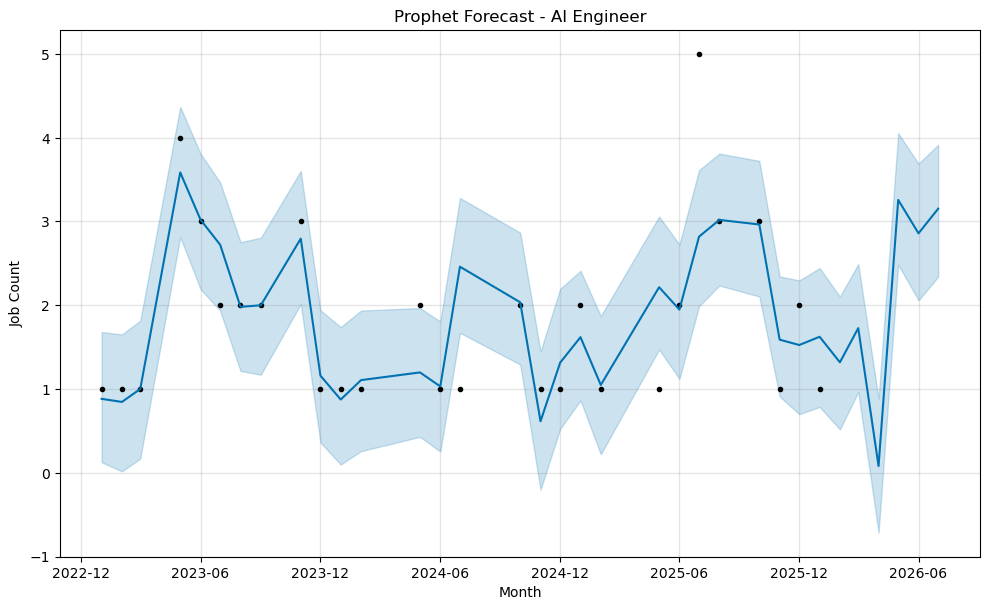

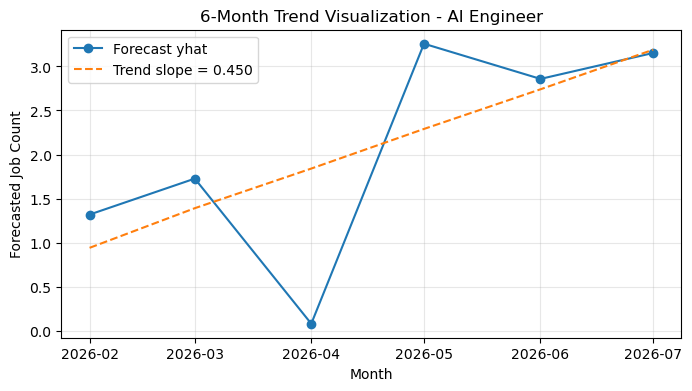

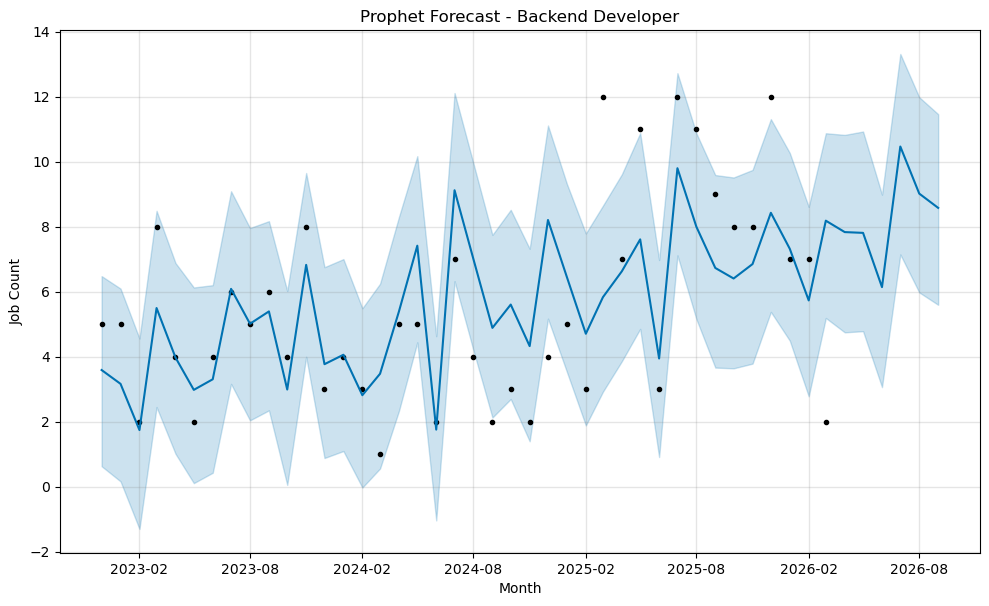

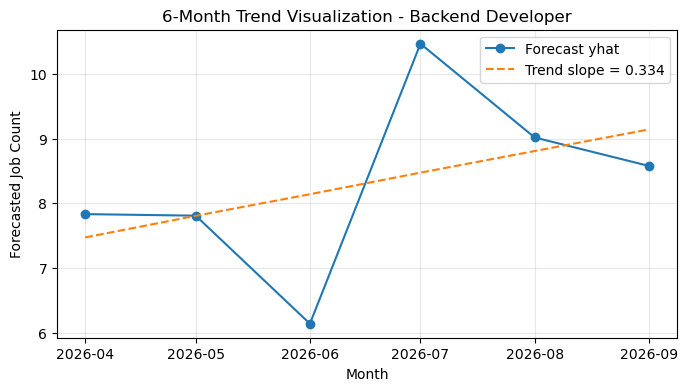

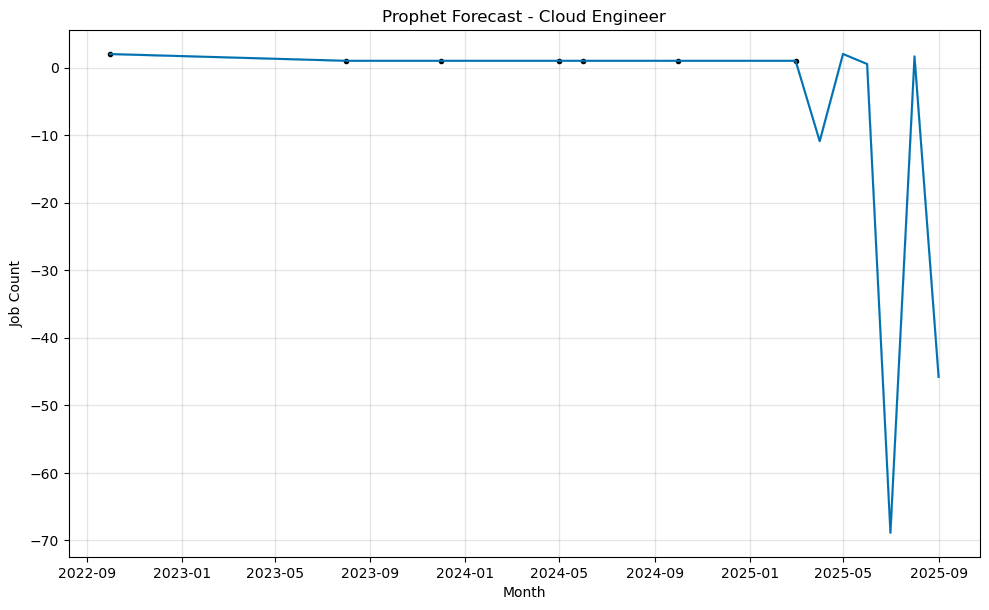

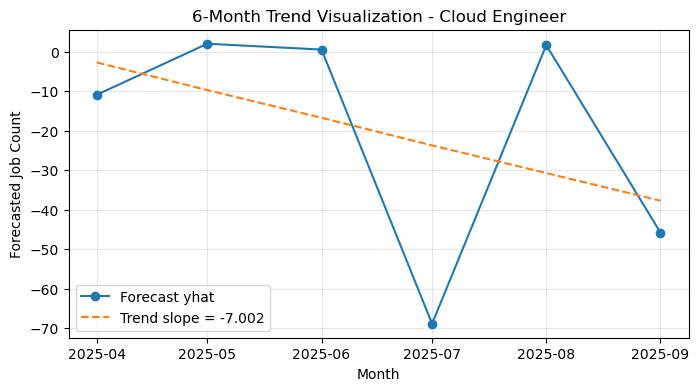

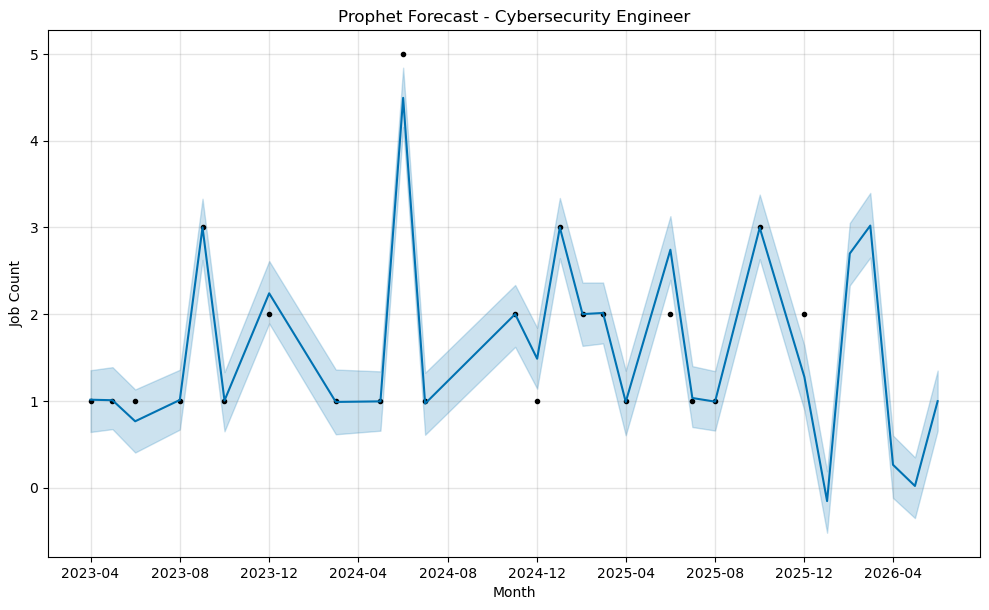

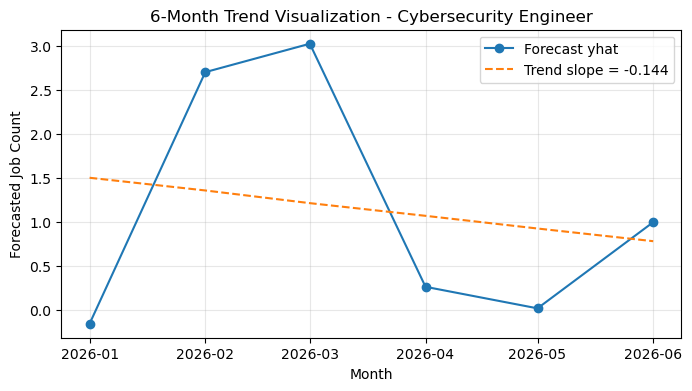

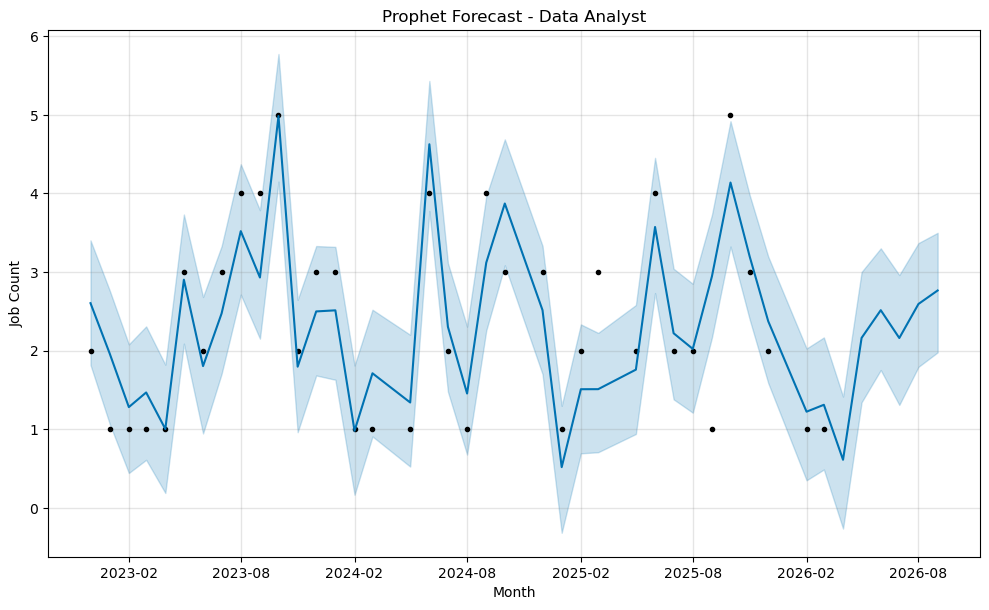

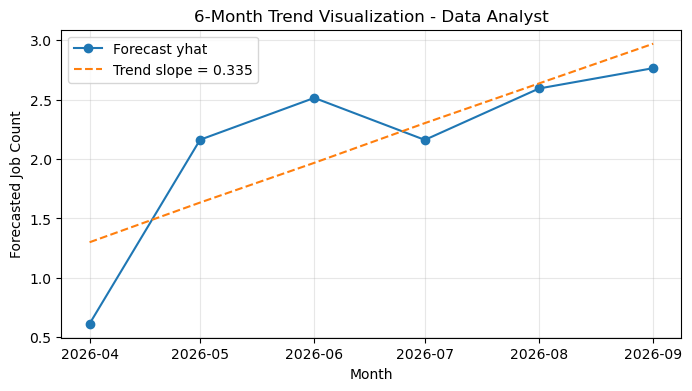

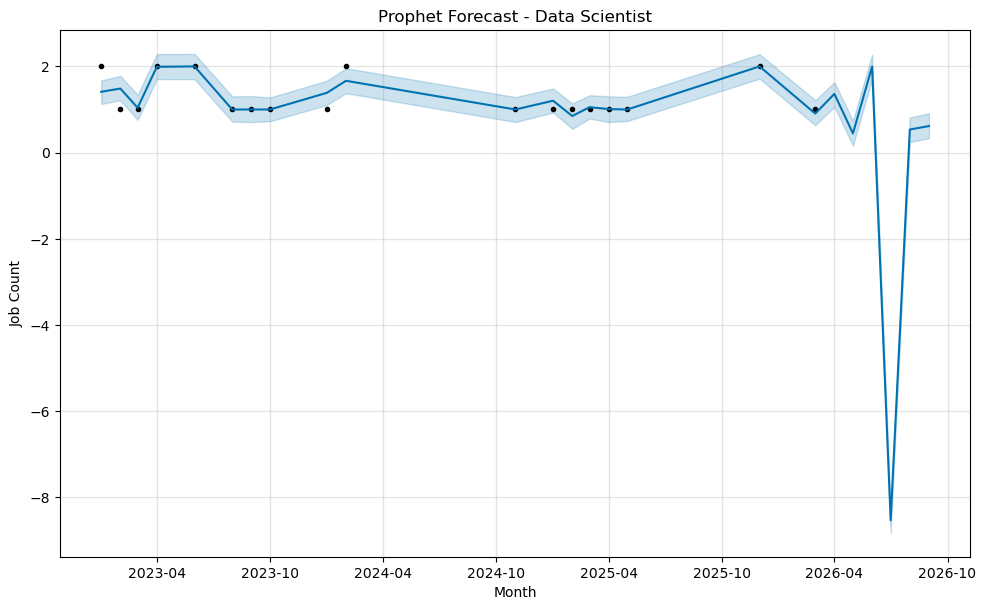

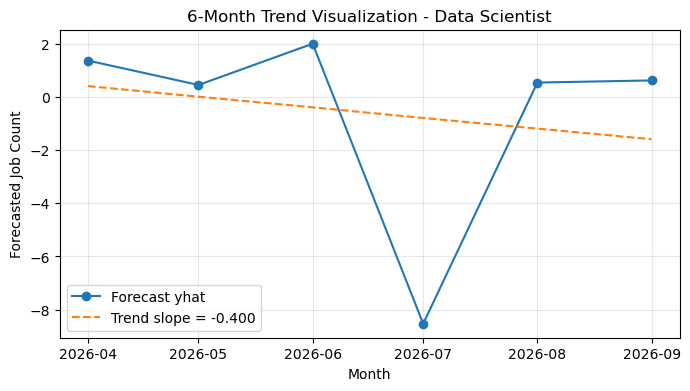

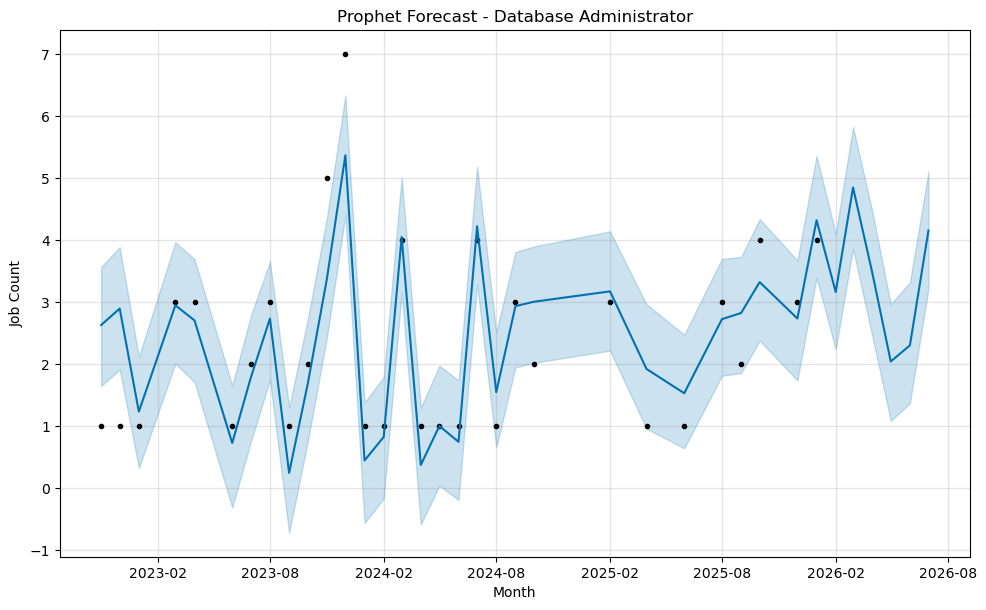

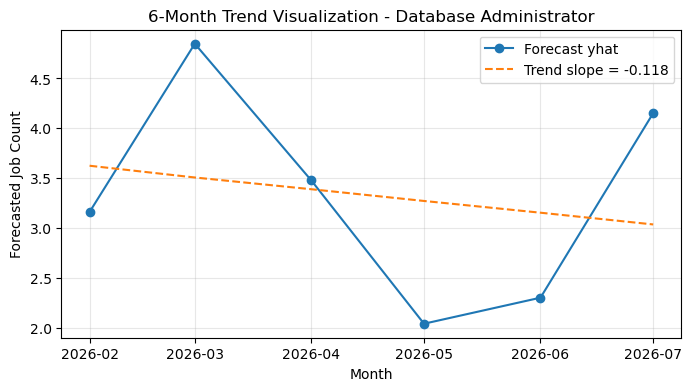

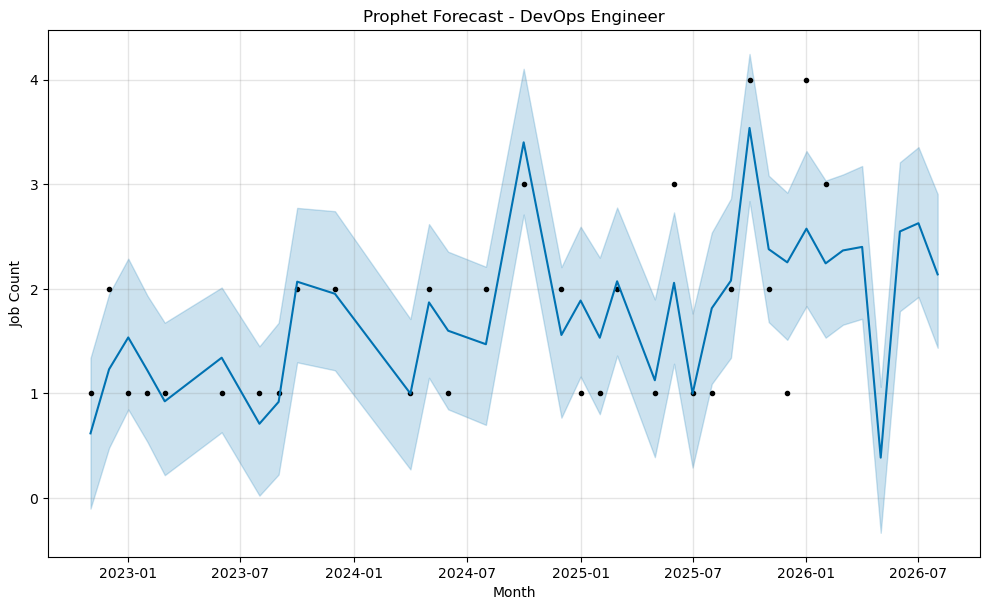

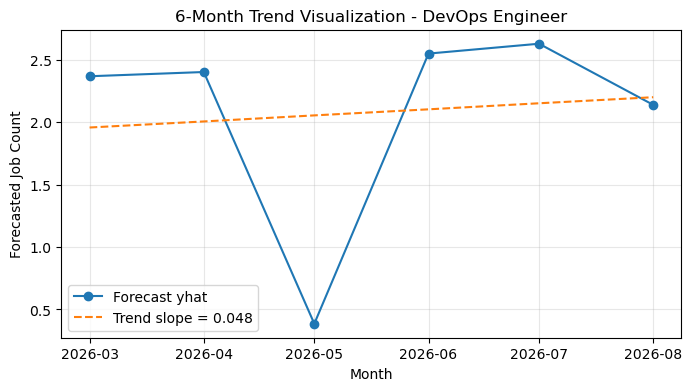

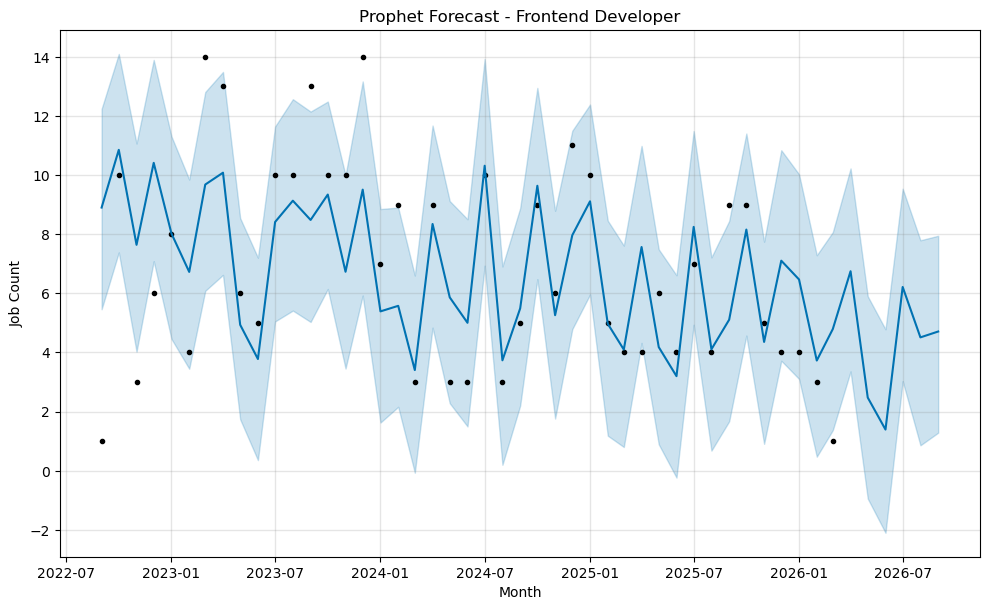

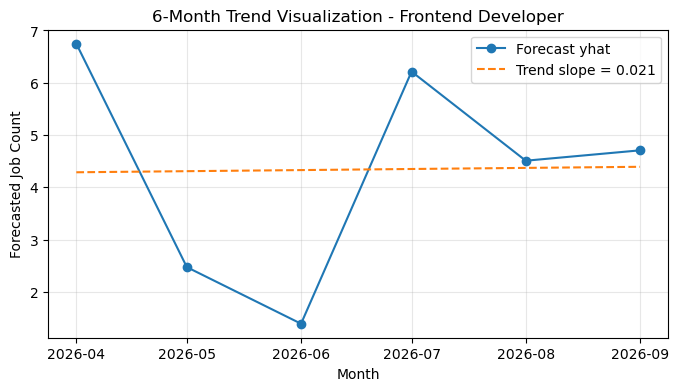

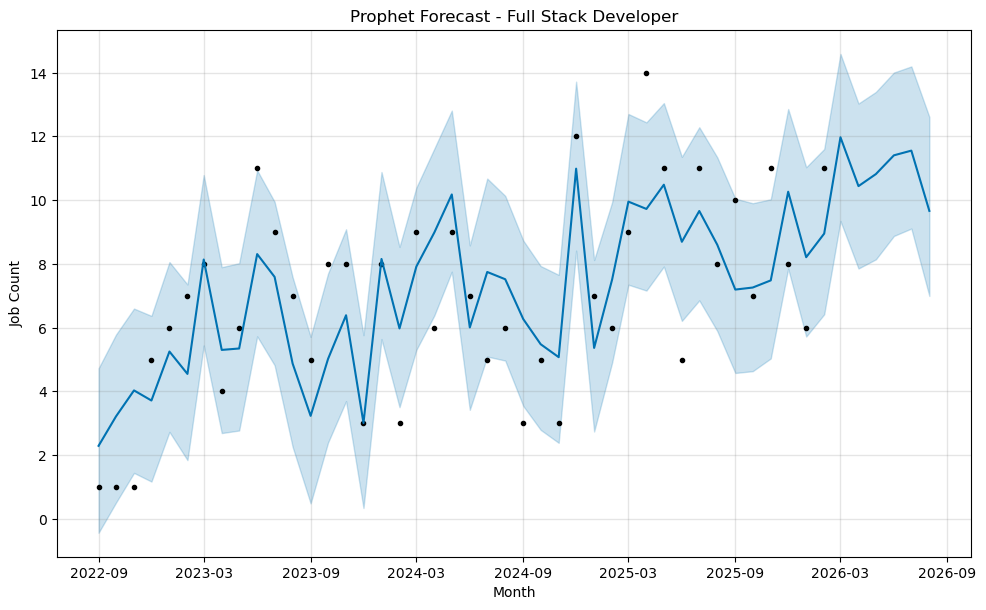

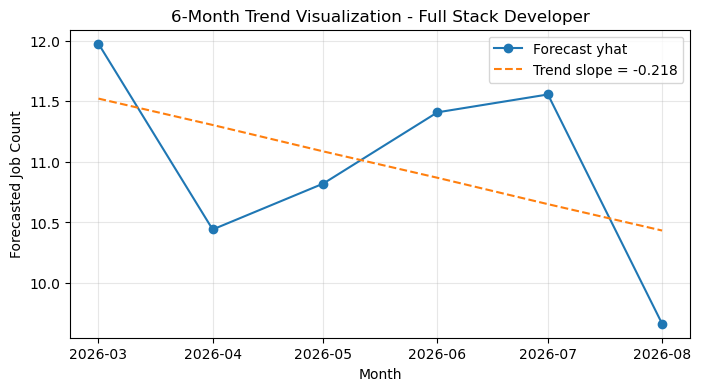

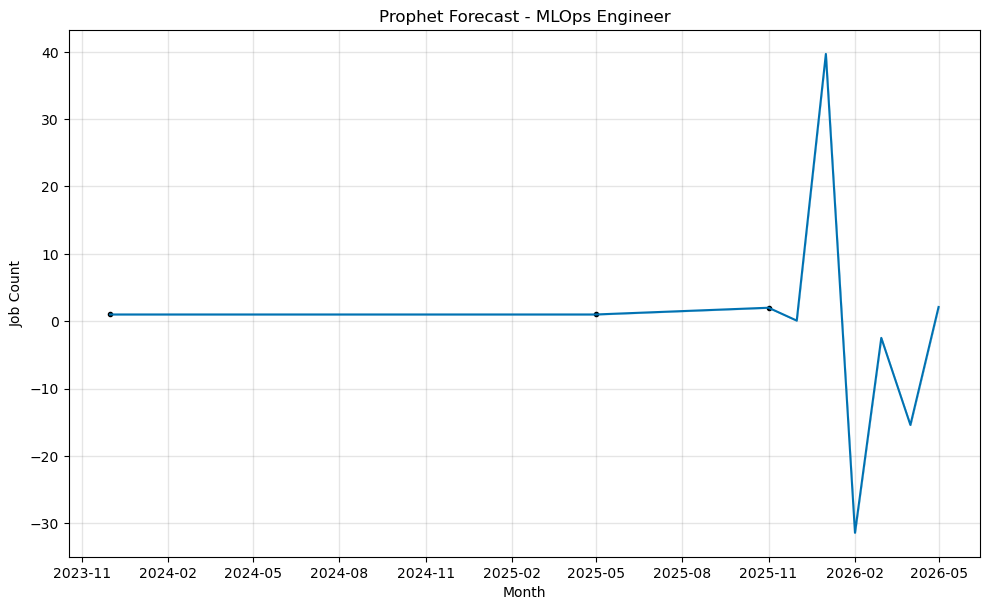

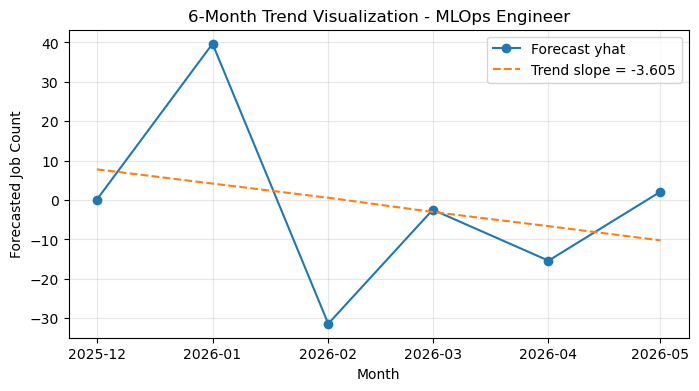

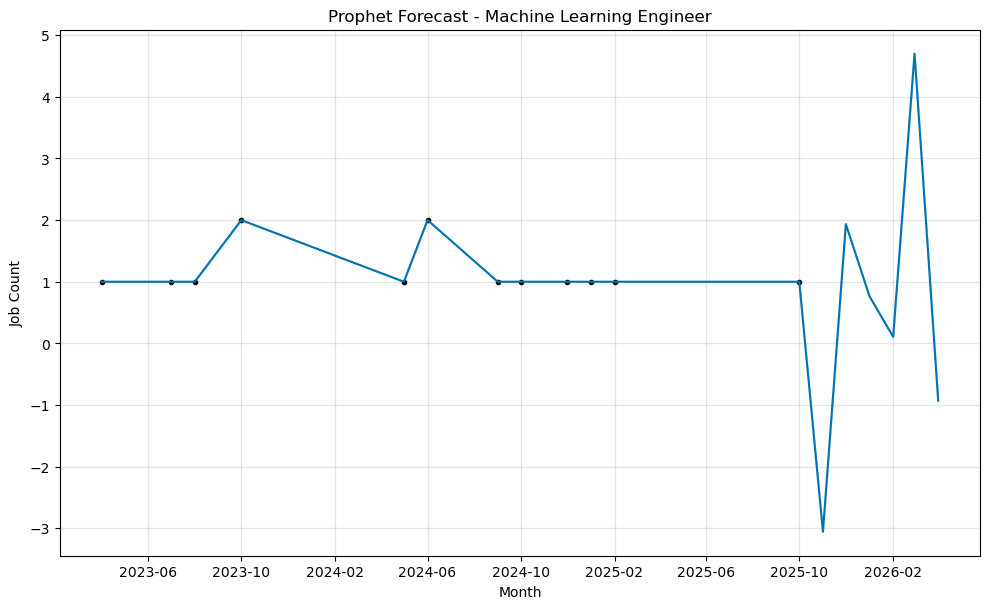

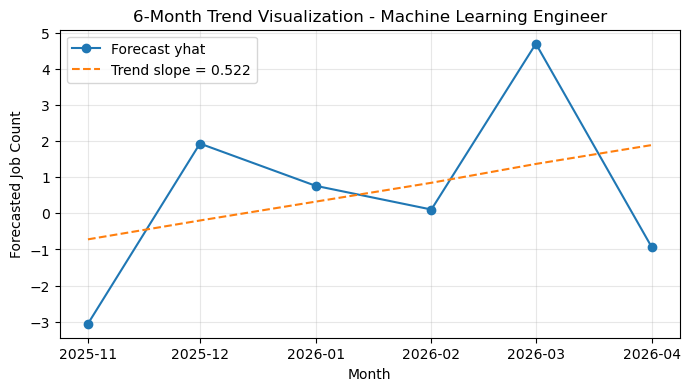

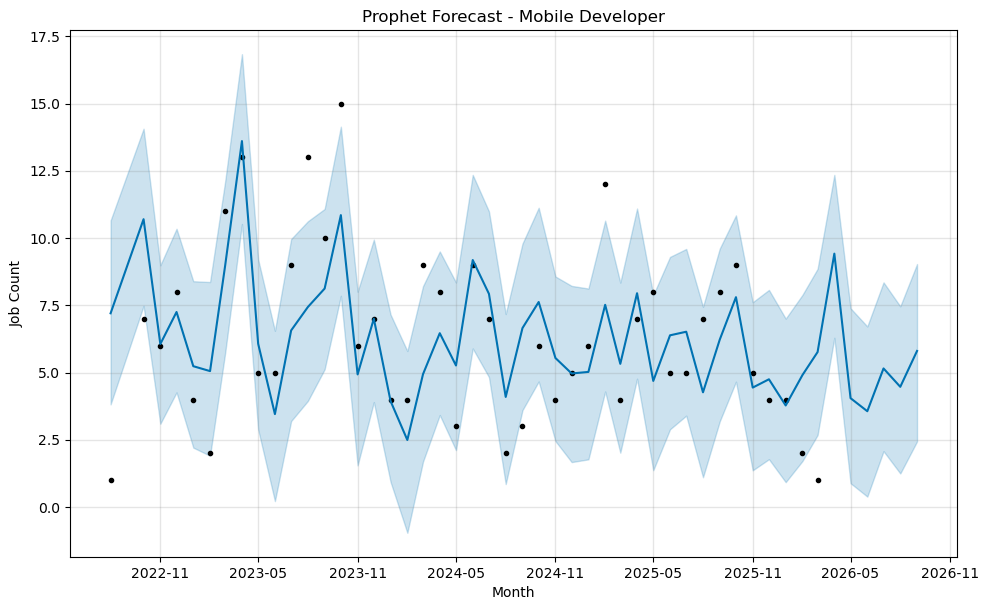

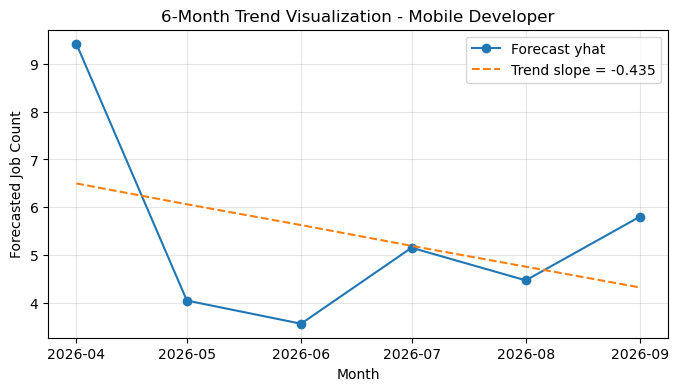

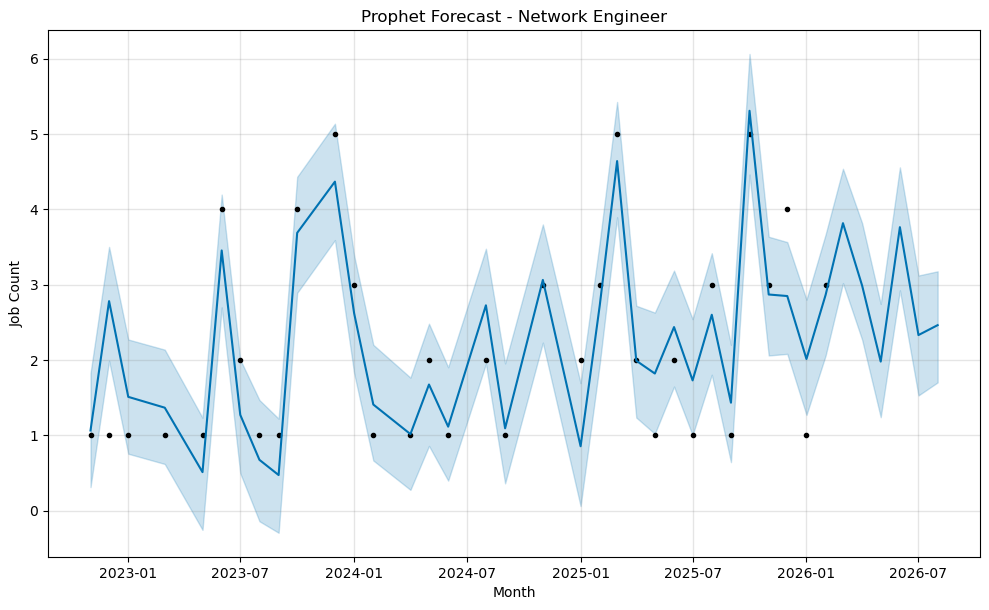

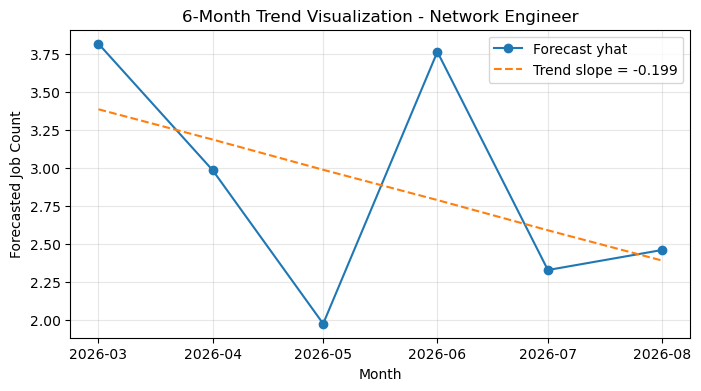

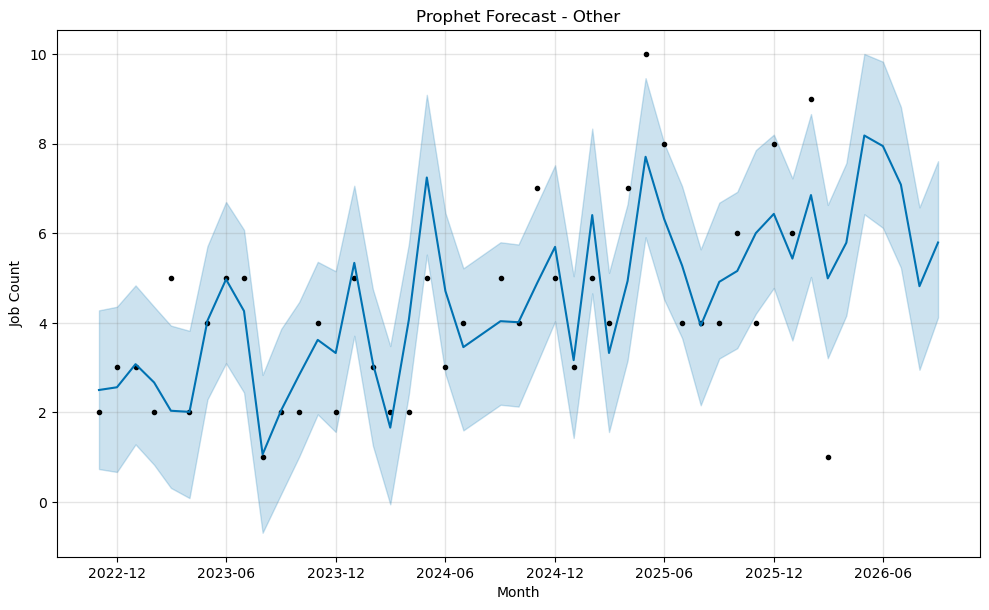

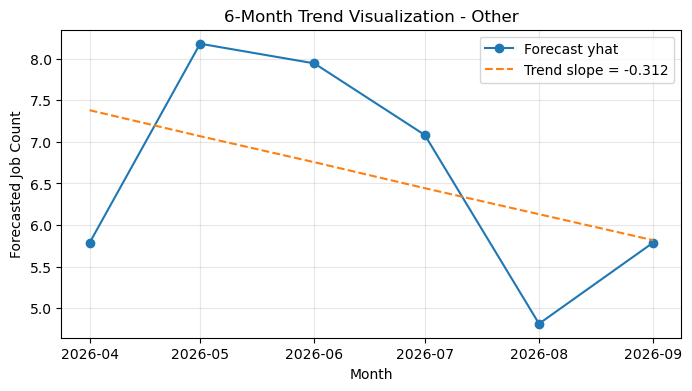

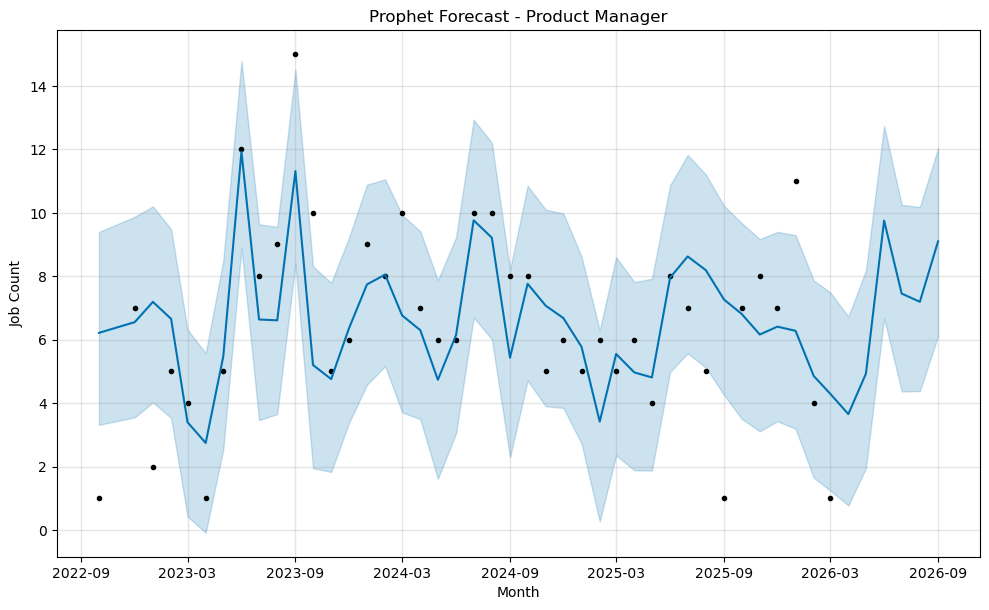

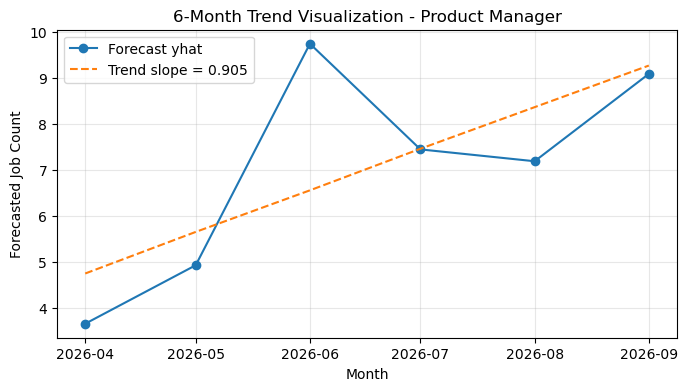

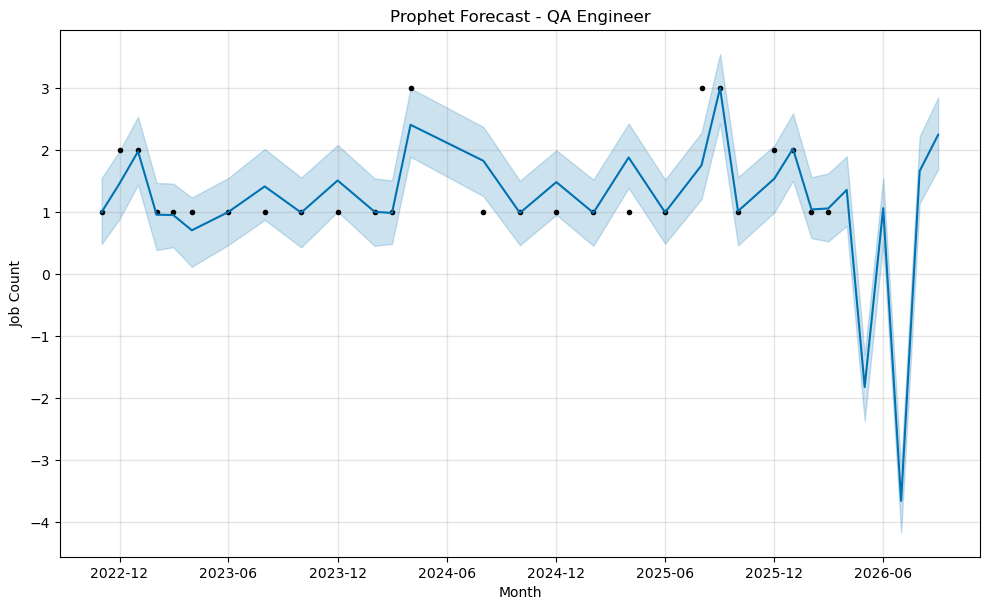

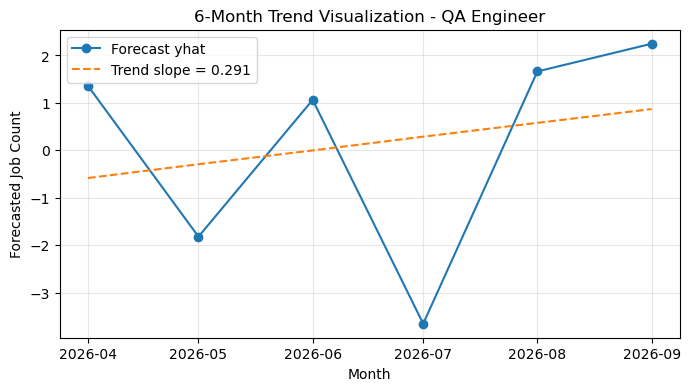

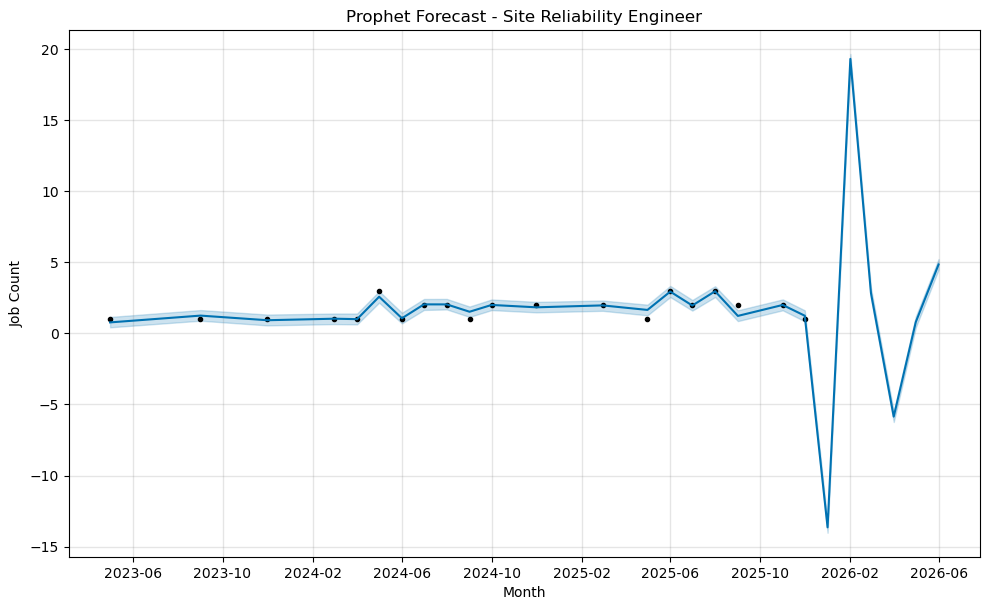

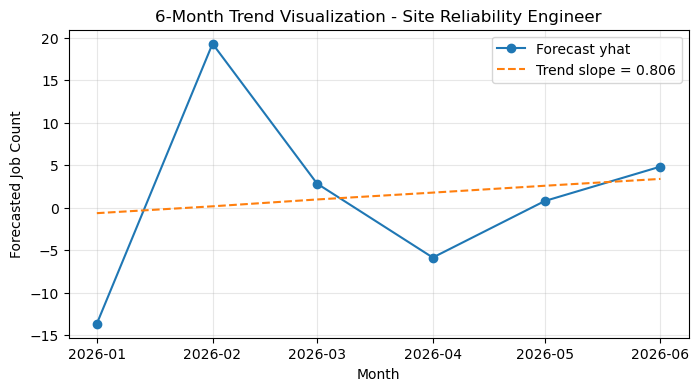

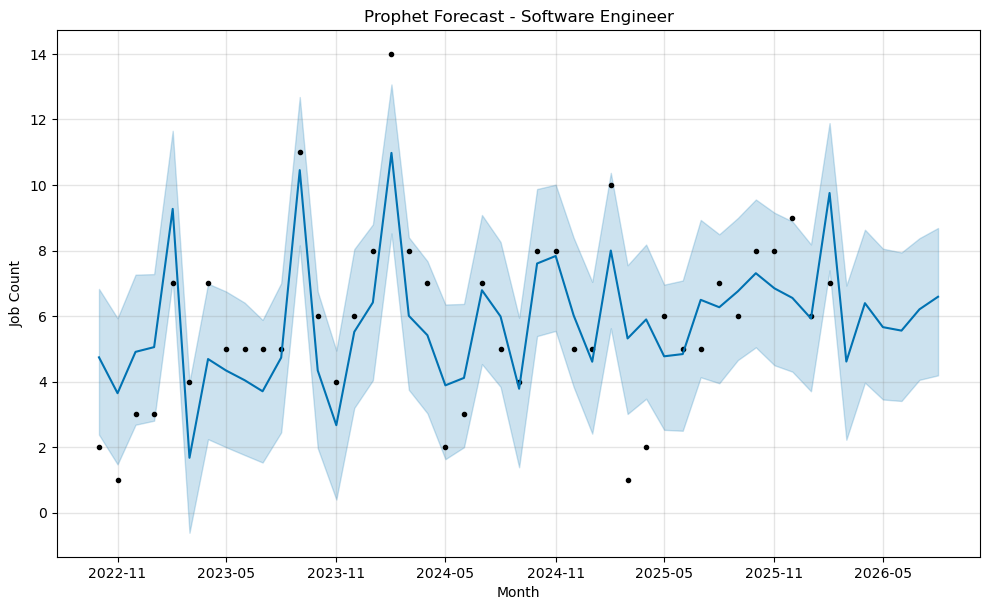

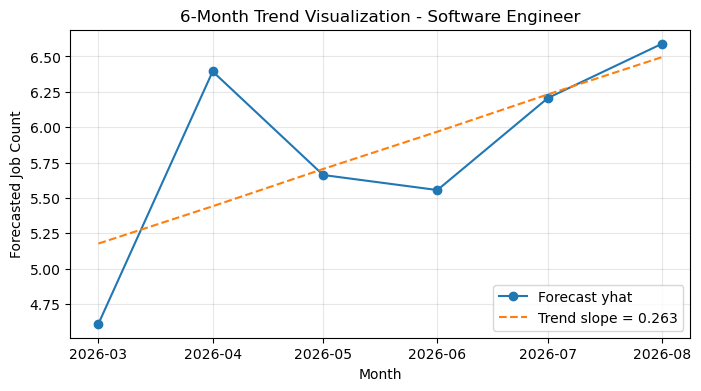

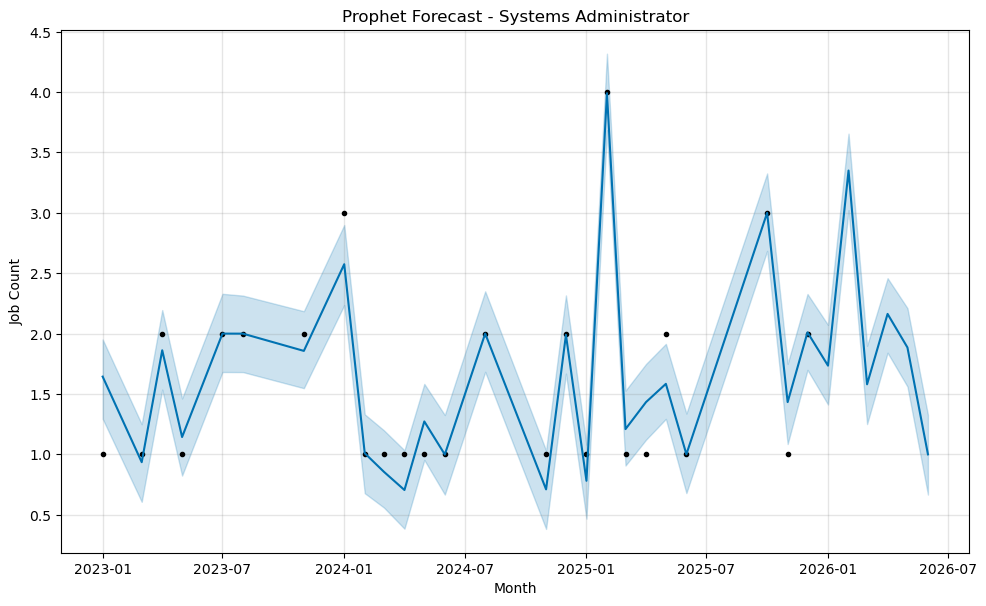

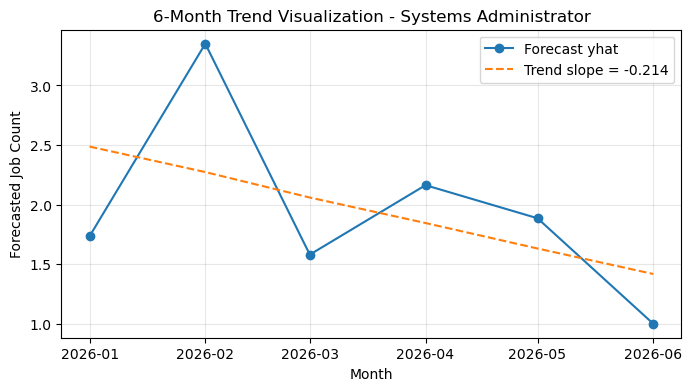

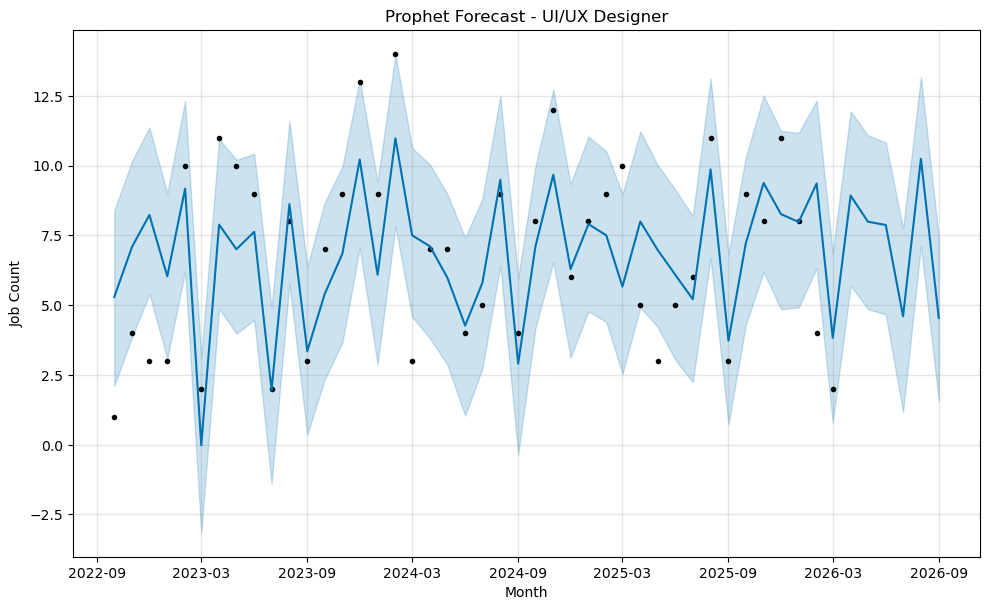

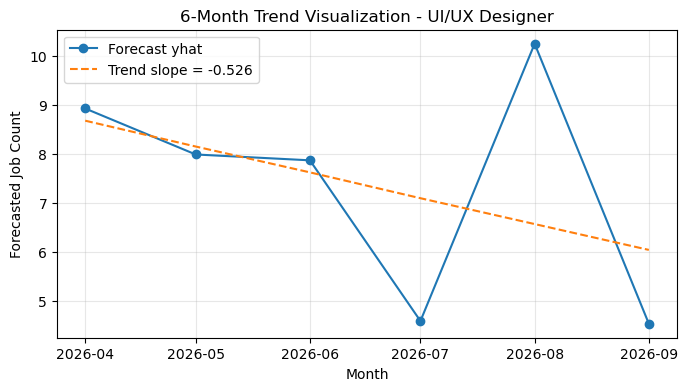

In [8]:
# Step 10: Plot Prophet forecasts and trend lines per role
for role, model in prophet_models.items():
    forecast_df = prophet_forecasts[role]

    fig = model.plot(forecast_df)
    plt.title(f"Prophet Forecast - {role}")
    plt.xlabel("Month")
    plt.ylabel("Job Count")
    plt.show()

    trend_slice = forecast_df.tail(horizon_months)[["ds", "yhat"]].copy()
    x = np.arange(len(trend_slice))
    slope, intercept = np.polyfit(x, trend_slice["yhat"].values, 1)

    plt.figure(figsize=(8, 4))
    plt.plot(trend_slice["ds"], trend_slice["yhat"], marker="o", label="Forecast yhat")
    plt.plot(
        trend_slice["ds"],
        slope * x + intercept,
        linestyle="--",
        label=f"Trend slope = {slope:.3f}",
    )
    plt.title(f"6-Month Trend Visualization - {role}")
    plt.xlabel("Month")
    plt.ylabel("Forecasted Job Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
# Step 11: Save models and pipeline outputs
def slugify_role(role: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", role.lower()).strip("_")

# Save Prophet models as prophet_<role>.pkl
saved_models = []
for role, model in prophet_models.items():
    file_name = f"prophet_{slugify_role(role)}.pkl"
    model_path = MODELS_DIR / file_name
    joblib.dump(model, model_path)
    saved_models.append(str(model_path))

# Save core modeling table in required format: month | role | job_count
modeling_export_path = OUTPUT_DIR / "modeling_dataset_month_role_job_count.csv"
modeling_df.to_csv(modeling_export_path, index=False)

# Save combined Prophet forecast output
if prophet_forecasts:
    prophet_export = []
    for role, forecast_df in prophet_forecasts.items():
        keep_cols = ["ds", "yhat", "yhat_lower", "yhat_upper"]
        temp = forecast_df[keep_cols].copy()
        temp["role"] = role
        prophet_export.append(temp)
    prophet_export_df = pd.concat(prophet_export, ignore_index=True)
    prophet_export_df.to_csv(FORECASTS_DIR / "prophet_forecasts_all_roles.csv", index=False)

# Save combined ARIMA forecast output
if arima_forecasts:
    arima_export = []
    for role, forecast_df in arima_forecasts.items():
        temp = forecast_df.copy()
        temp["role"] = role
        arima_export.append(temp)
    arima_export_df = pd.concat(arima_export, ignore_index=True)
    arima_export_df.to_csv(FORECASTS_DIR / "arima_forecasts_all_roles.csv", index=False)

# Save evaluation and trend tables
if not evaluation_df.empty:
    evaluation_df.to_csv(METRICS_DIR / "model_evaluation_by_role.csv", index=False)
if not trend_df.empty:
    trend_df.to_csv(METRICS_DIR / "trend_scores_by_role.csv", index=False)

print(f"Saved Prophet models: {len(saved_models)}")
print(f"Modeling table: {modeling_export_path}")
print(f"Forecast outputs: {FORECASTS_DIR}")
print(f"Metrics outputs: {METRICS_DIR}")

Saved Prophet models: 21
Modeling table: c:\Users\user\Desktop\5th\VentureScope\Data-ML\model\timeseries\artifacts\modeling_dataset_month_role_job_count.csv
Forecast outputs: c:\Users\user\Desktop\5th\VentureScope\Data-ML\model\timeseries\artifacts\forecasts
Metrics outputs: c:\Users\user\Desktop\5th\VentureScope\Data-ML\model\timeseries\artifacts\metrics
